# Oppgave 2

In [18]:
# Importerer nødvenige bibliotek og setter plot størrelse
import numpy as np
import matplotlib.pyplot as plt
import scipy

plt.rcParams['figure.figsize'] = [10, 6]

## a)

In [4]:
def matrixToVector(M):
    # Initialiserer en null vektor dobbel så lang som antall elementer i matrisen(2*4)
    v = np.zeros(2 * M.size)

    # itererer for alle i og j og henter ut den reelle- og imaginære delen 4(M.size) steg unna hverandre
    for i, j in np.ndindex(M.shape):
        v[i * M.shape[1] + j] = np.real(M[i, j])
        v[M.size + i * M.shape[1] + j] = np.imag(M[i, j])
    return v

def vectorToMatrix(v):
    # Initialiserer en 2x2 kompleks nullmatrise
    M = np.zeros((2, 2), dtype=complex)

    # plasserer de reelle og imaginære komponentene, 4 steg unna hverandre, inn i matrisen
    for i, j in np.ndindex(M.shape):
        M[i, j] = v[i * M.shape[1] + j] + 1j * v[M.size + i * M.shape[1] + j]
    return M

# Tester koden
M = np.array([[1+5j, 2+6j],
              [3+7j, 4+8j]])   
print(f"Matrise: \n{M}")

v = matrixToVector(M)
print(f"Matrise gjort om til vektor: \n{v}")
M_reconstructed = vectorToMatrix(v)
print(f"Transformasjon og invers transformasjon av matrise: \n{M_reconstructed}")

Matrise: 
[[1.+5.j 2.+6.j]
 [3.+7.j 4.+8.j]]
Matrise gjort om til vektor: 
[1. 2. 3. 4. 5. 6. 7. 8.]
Transformasjon og invers transformasjon av matrise: 
[[1.+5.j 2.+6.j]
 [3.+7.j 4.+8.j]]


## b)

In [5]:
def combineVectors(m1, m2, m3, m4):
    # Bruker np.concatenate for å samle vektorene inn i en vektor
    return np.concatenate((m1, m2, m3, m4))

def seperateVectors(v):
    # Bruker np.split for å splitte en vektor til fire mindre vektorer 
    return  np.array_split(v, 4)

# Tester koden
m1 = np.array([1, 2, 3])
m2 = np.array([4, 5, 6])
m3 = np.array([7, 8, 9])
m4 = np.array([10, 11, 12])

result = combineVectors(m1, m2, m3, m4)
print(f"Fire vektorer slått sammen til en: \n{result}")

print("Sammenslått vektor splittet til fire vektorer: ")
for vec in seperateVectors(result):
    print(vec, end=" ")

Fire vektorer slått sammen til en: 
[ 1  2  3  4  5  6  7  8  9 10 11 12]
Sammenslått vektor splittet til fire vektorer: 
[1 2 3] [4 5 6] [7 8 9] [10 11 12] 

## c)

In [6]:
def vector32FromFour2DMatrices(gamma, gammaTilde, omega, omegaTilde):
    # Legger sammen kombineringsfunksjonen og matrise-til-vektor-funksjonen
    return combineVectors(matrixToVector(gamma), matrixToVector(gammaTilde), matrixToVector(omega), matrixToVector(omegaTilde))

def four2DMatricesFromvector32(v):
    # Separerer først v til fire matrisevektorer og gjør dem deretter om til matriser
    m1, m2, m3, m4 = seperateVectors(v) 
    return vectorToMatrix(m1), vectorToMatrix(m2), vectorToMatrix(m3), vectorToMatrix(m4)


# Tester koden
gamma = np.array([[1+2j, 3+4j], [5+6j, 7+8j]])
gammaTilde = np.array([[9+10j, 11+12j], [13+14j, 15+16j]])
omega = np.array([[17+18j, 19+20j], [21+22j, 23+24j]])
omegaTilde = np.array([[25+26j, 27+28j], [29+30j, 31+32j]])

v = vector32FromFour2DMatrices(gamma, gammaTilde, omega, omegaTilde)
print("Kombinert vektor v:\n", v)

gamma_res, gammaTilde_res, omega_res, omegaTilde_res = four2DMatricesFromvector32(v)
print("Ricatti matrisene hentet ut av v: \nGamma: \n", gamma_res)
print("GammaTilde: \n", gammaTilde_res)
print("Gmega: \n", omega_res)
print("GmegaTilde: \n", omegaTilde_res)

Kombinert vektor v:
 [ 1.  3.  5.  7.  2.  4.  6.  8.  9. 11. 13. 15. 10. 12. 14. 16. 17. 19.
 21. 23. 18. 20. 22. 24. 25. 27. 29. 31. 26. 28. 30. 32.]
Ricatti matrisene hentet ut av v: 
Gamma: 
 [[1.+2.j 3.+4.j]
 [5.+6.j 7.+8.j]]
GammaTilde: 
 [[ 9.+10.j 11.+12.j]
 [13.+14.j 15.+16.j]]
Gmega: 
 [[17.+18.j 19.+20.j]
 [21.+22.j 23.+24.j]]
GmegaTilde: 
 [[25.+26.j 27.+28.j]
 [29.+30.j 31.+32.j]]


## d)

In [7]:
def derivative(v):
    delta = 0.01

    # Henter ut ricatti matrisene fra v
    gamma, gammaTilde, omega, omegaTilde = four2DMatricesFromvector32(v)

    # Definerer en identitetsmatrise og beregner N og N tilde matrisene
    I = np.eye(2)
    N = np.linalg.inv(I - (gamma @ gammaTilde))
    Ntilde = np.linalg.inv(I - (gammaTilde @ gamma))

    # Bruker Usadel ligningene for å regne ut de deriverte av Ricatti matrisene
    dgamma = omega
    dgammaTilde = omegaTilde
    domega = -2*1j * (epsilon + 1j*delta)*gamma - 2* omega @ Ntilde @ gammaTilde @ omega   
    domegaTilde = -2*1j * (epsilon + 1j*delta)*gammaTilde - 2* omegaTilde @ N  @ gamma @ omegaTilde

    # Returnerer den deriverte som en vektor på samme form som v
    return vector32FromFour2DMatrices(dgamma, dgammaTilde, domega, domegaTilde)

## e)

In [8]:
def derivativeForPosition(x, vec):
    vecDerivative = np.zeros_like(vec) # VecDerivative som returneres får 32xm dimensjoner til bruk i solve_bvp
    for i in range(x.size):
        vecDerivative[:, i] = derivative(vec[:, i]) # Bruker derivative funksjonen på alle v(x) i vec
    return vecDerivative

Siden vec har dimensjon (32, m), med matrisevektoren v(x) i hver kolonne, bruker vi vec[:, i] for å hente ut den i'te kolonnen. Man kan da bruke derivative funksjonen på v(x) og legge den inn i vecDerivative.

## f)

In [9]:
def boundaryConditionsNormal(vLeft, vRight):
    zeta = 3
    # Siden det er et vanlig metall er Ricattimatrisene 2x2 nullmatriser
    gammaL = np.zeros((2,2))
    gammaTildeL = np.zeros((2,2))
    gammaR = np.zeros((2,2))
    gammaTildeR = np.zeros((2,2))

    # Henter ut Ricatti matrisene til venstre og høyre side av det normale metallet
    gamma0, gammaTilde0, omega0, omegaTilde0 = four2DMatricesFromvector32(vLeft)
    gammaEnd, gammaTildeEnd, omegaEnd, omegaTildeEnd = four2DMatricesFromvector32(vRight)

    # Definerer nødvendige matriser
    I = np.eye(2)
    NLeft = np.linalg.inv(I - (gammaL @ gammaTildeL))
    NLeftTilde = np.linalg.inv(I - (gammaTildeL @ gammaL))
    NRight = np.linalg.inv(I - (gammaR @ gammaTildeR))
    NRightTilde = np.linalg.inv(I - (gammaTildeR @ gammaR))

    # Grensebetingelser venstre side ved likn 13-16
    bcl1 = omega0 + 1/(zeta*l) * (I - gamma0 @ gammaTildeL) @ NLeft @ (gammaL - gamma0)
    bcl2 = omegaTilde0 + 1/(zeta*l) * (I - gammaTilde0 @ gammaL) @ NLeftTilde @ (gammaTildeL - gammaTilde0)
    # Grensebetingelser høyre side ved likn 13-16
    bcr1 = omegaEnd - 1/(zeta*l) * (I - gammaEnd @ gammaTildeR) @ NRight @ (gammaR - gammaEnd)
    bcr2 = omegaTildeEnd - 1/(zeta*l) * (I - gammaTildeEnd @ gammaR) @ NRightTilde @ (gammaTildeR - gammaTildeEnd)

    # Returnerer grensebetingelsene som en 32 lang vektor
    return vector32FromFour2DMatrices(bcl1, bcl2, bcr1, bcr2)

## g)

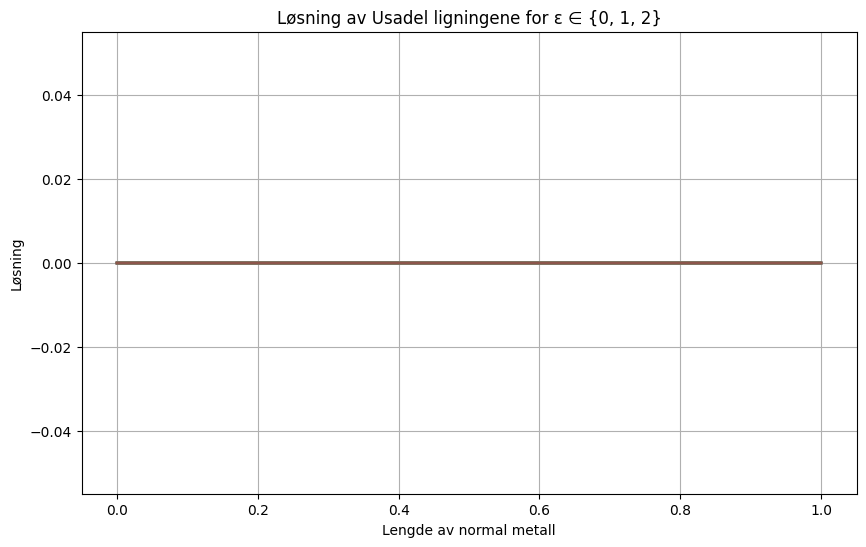

Alle elementene i y er null


In [ ]:
# Setter opp startbetingelser
l = 1
m = 101
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = [0, 1, 2]

# Itererer over forskjellige epsilon verdier, løser og plotter Usadel ligningene
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsNormal, x, y)
    plt.plot(x, sol.sol(x).T)

plt.ylabel("Løsning")
plt.xlabel("Lengde av normal metall")
plt.title("Løsning av Usadel ligningene for ε ∈ {0, 1, 2}")
plt.grid(True)
plt.show()

# Kontrollere at alle elementene i y er null
assert np.all(y == 0), "Noen elementer i y er ikke null"
print("Alle elementene i y er null")

Her kan man se på plottet at alle deler av løsningen er null, og assert funksjonen forteller oss det samme. Siden det normale metallet er koblet til to andre normale metall, vil hele løsningen være lik null.

## h)

In [11]:
def densityOfStates(x, vec):
    rho3 = np.block([[np.eye(2), np.zeros((2, 2))],
            [np.zeros((2, 2)), -np.eye(2)]])

    # For at funksjonen skal fungere dersom man sender inn kun en x verdi og vec med dim(32,1)
    if len(x) == 1:
        gamma, gammaTilde, _, _ = four2DMatricesFromvector32(vec)
        I = np.eye(2)
        N = np.linalg.inv(I - (gamma @ gammaTilde))
        NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
        g = np.block([[(2*N - I), (2*N @ gamma)],
        [(-2*NTilde @ gammaTilde), (-2*NTilde + I)]])
        
        dos = (np.real(np.trace(rho3 @ g))/4)
    
    else:
        dos = []
        for i in range(len(x)):
            gamma, gammaTilde, _, _ = four2DMatricesFromvector32(vec[:,i])
            I = np.eye(2)
            N = np.linalg.inv(I - (gamma @ gammaTilde))
            NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
            g = np.block([[(2*N - I), (2*N @ gamma)],
            [(-2*NTilde @ gammaTilde), (-2*NTilde + I)]])

            dos.append(np.real(np.trace(rho3 @ g))/4)
     
    return dos

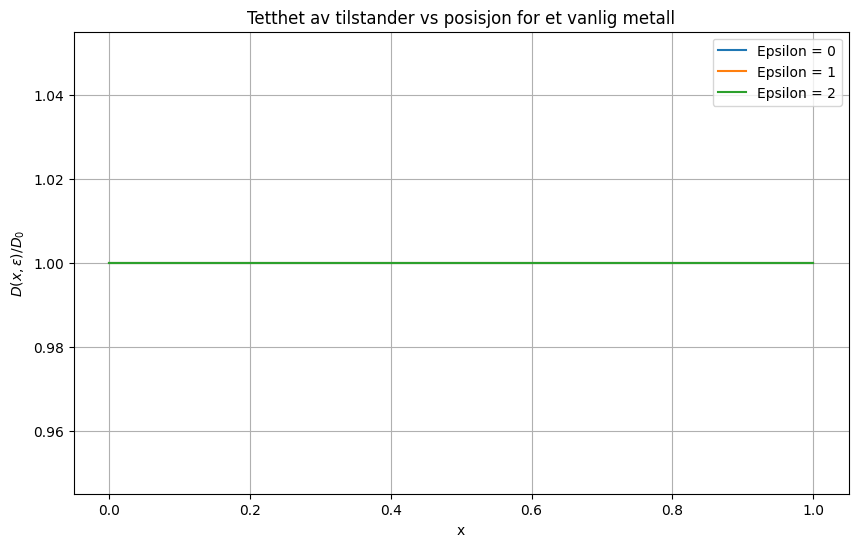

In [ ]:
# Setter opp startbetingelser
l = 1
m = 101
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = [0, 1, 2]

# Itererer over forskjellige epsilons, løser Usadel ligningene og plotter tettheten av tilstander for løsningen
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsNormal, x, y)
    DOS = densityOfStates(x, sol.sol(x))
    plt.plot(x, DOS, label=f"Epsilon = {epsilon}")

plt.ylabel("$D(x,ε)/D_0$")
plt.xlabel("x")
plt.title("Tetthet av tilstander vs posisjon for et vanlig metall")
plt.grid(True)
plt.legend()
plt.show()

Her ser man at tettheten av tilstander ikke endrer seg fra referanse tettheten $D_0$. Dette skjer siden det er et normalt metall koblet med to normale metaller.

## i)

In [14]:
def boundaryConditionsSuperconductor(vLeft, vRight):
    zeta = 3
    delta = 0.01

    # Definerer s og c for beregning av Ricatti matrisene til superlederne
    s = np.sinh(np.arctanh(1/(epsilon+delta*1j)))
    c = np.cosh(np.arctanh(1/(epsilon + delta*1j)))

    # Regner ut Ricatti matrisene til superlederne
    gammaL = np.block([[0, +s/(1+c)],
                      [-s/(1+c), 0]]) * np.exp(1j*phiL)
    gammaTildeL = np.block([[0, -s/(1+c)],
                      [+s/(1+c), 0]]) * np.exp(-1j*phiL)
    gammaR = np.block([[0, +s/(1+c)],
                      [-s/(1+c), 0]]) * np.exp(1j*phiR)
    gammaTildeR = np.block([[0, -s/(1+c)],
                      [+s/(1+c), 0]]) * np.exp(-1j*phiR)

    # Henter ut Ricatti matrisene fra det normale metallet fra venstre og høyre siden
    gamma0, gammaTilde0, omega0, omegaTilde0 = four2DMatricesFromvector32(vLeft)
    gammaEnd, gammaTildeEnd, omegaEnd, omegaTildeEnd = four2DMatricesFromvector32(vRight)

    # Definerer nødvendige matriser
    I = np.eye(2)
    NLeft = np.linalg.inv(I - (gammaL @ gammaTildeL))
    NLeftTilde = np.linalg.inv(I - (gammaTildeL @ gammaL))
    NRight = np.linalg.inv(I - (gammaR @ gammaTildeR))
    NRightTilde = np.linalg.inv(I - (gammaTildeR @ gammaR))

    # Innfører grensebetingelsene
    bcl1 = omega0 + 1/(zeta*l) * (I - gamma0 @ gammaTildeL) @ NLeft @ (gammaL - gamma0)
    bcl2 = omegaTilde0 + 1/(zeta*l) * (I - gammaTilde0 @ gammaL) @ NLeftTilde @ (gammaTildeL - gammaTilde0)
    bcr1 = omegaEnd - 1/(zeta*l) * (I - gammaEnd @ gammaTildeR) @ NRight @ (gammaR - gammaEnd)
    bcr2 = omegaTildeEnd - 1/(zeta*l) * (I - gammaTildeEnd @ gammaR) @ NRightTilde @ (gammaTildeR - gammaTildeEnd)

    # Legger sammen grensebetingelsene til en vektor
    return vector32FromFour2DMatrices(bcl1, bcl2, bcr1, bcr2)

For å forklare hvordan vi har regnet ut Ricatti matrisene til superlederne:

Siden $sinh(z)$ er en odde funksjon og $cosh(z)$ er en like funksjon, er $tanh(z) = \frac{sinh(z)}{cosh(z)}$ en odde funksjon.  
Da må også $atanh(z)$ være odde. Da vil $sinh(atanh(-z)) = -sinh(atanh(z))$ og $cosh(atanh(-z)) = cosh(atanh(z))$.  
Dette gjør at $s_- = -s_+$ og $c_- = c_+$.

Dette er hvorfor vi har kun definert $s$ og $c$, og ikke $s_-$, $s_+$, $c_-$ og $c_+$.

## j)

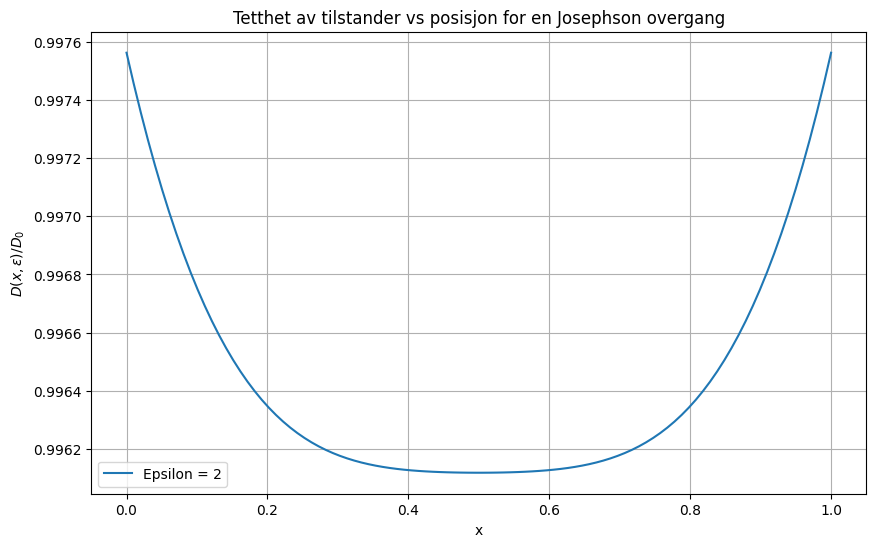

In [ ]:
# Setter opp startbetingelser
l = 1
m = 100
phiL = 0
phiR = 0
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilon = 2

# Løser Usadel ligninene for en Josephson overgang og plotter tettheten av tilstander til løsningen
sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
DOS = densityOfStates(x, sol.sol(x))
plt.plot(x, DOS, label=f"Epsilon = {epsilon}")
plt.ylabel("$D(x,ε)/D_0$")
plt.xlabel("x")
plt.title("Tetthet av tilstander vs posisjon for en Josephson overgang")
plt.grid(True)
plt.legend()
plt.show()


Når $\epsilon = \frac{E - E_f}{\left|\Delta\right|} = 2$ betyr det at $E - E_f = 2\left|\Delta\right|$. Når energien er så stor, er det så å si ingen superleder egenskaper i superlederne og da heller ikke i metallet. 

Tettheten av tilstander til en superleder ved $\epsilon = 2$ er ca $1.1$, altså litt større enn standard tettheten $D_0$. Det at det er flere tilstander i superlederne gjør at det vil være mer gunstig for elektronene å befinne seg i de "ekstra" tilstandene(til superlederne), og tettheten til den normale metallet vil derfor bli mindre. 

## k)

Integral: 1.0096299834269413
Integral: 1.0027749670486485
Integral: 0.9940905067785699


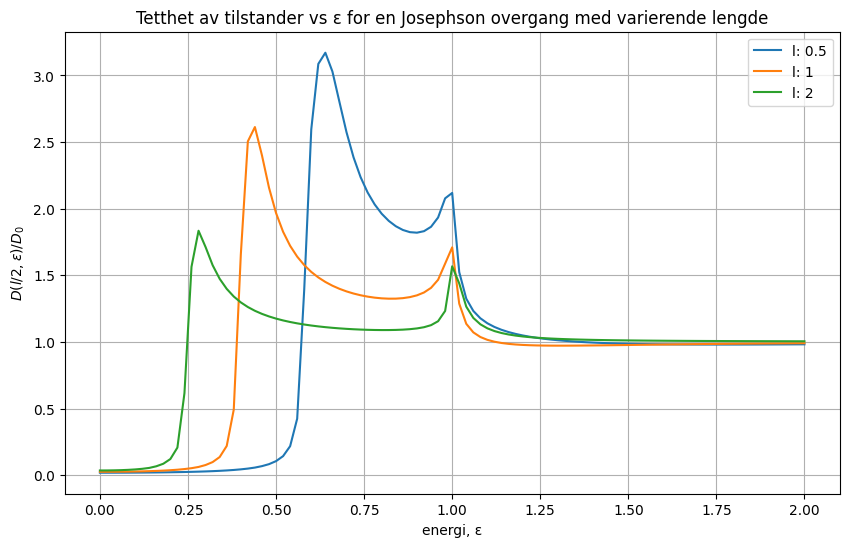

In [ ]:
# Setter opp startbetingelser som ikke endrer seg
ls = [0.5, 1, 2]
m = 100
x = np.linspace(0, l, m)
epsilons = np.linspace(2, 0, 101)

# Kjører koden for l=0.5, 1 og 2
for l in ls:
    # Begynner med en null løsning for epsilon=2
    y = np.zeros((32,m))
    # Itererer for 101 verdier av epsilon mellom 0 og 2
    DOS_values = np.zeros_like(epsilons)
    for j, epsilon in enumerate(epsilons):
        sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
        DOS = densityOfStates([l/2], sol.sol(l/2))
        DOS_values[j] = (DOS)
        # Setter initial gjettet, til løsningen for forrige epsilonverdi
        y = sol.sol(x)
        
    # Plotter tettheten av tilstander for x = l/2 og epsilon mellom 0 og 2
    plt.plot(epsilons, DOS_values, label=f"l: {l}")
    # Skriver ut den standeriserte mengden tilstander mellom epsilon = 0 og 2
    print(f"Integral: {-scipy.integrate.simpson(x=epsilons, y=DOS_values)/(abs(epsilons[0] - epsilons[-1]))}")

plt.ylabel("$D(l/2,ε)/D_0$")
plt.xlabel("energi, ε")
plt.title("Tetthet av tilstander vs ε for en Josephson overgang med varierende lengde")
plt.grid(True)
plt.legend()
plt.show()

Her kan du se at minigapet blir "kortere" når lengden av overgangen($l$) blir lengre. Dette skjer fordi superlederevnen må "lekke" igjennom mer materialet, som kun kan skje for mindre energinivå.

Når $l = 0.5$ observerer man at tettheten også blir større (litt over $3D_0$) ved $\epsilon = 0.5$. Etter denne "eksplosive" veksten, reduserer den stabilt fram mot $\epsilon = 1$ hvor en interaksjon i energigrensesnittet $\epsilon = 1$ øker tettheten igjen. Som man ser i figur 1 i oppgave beskrivelsen, har superlederne på $x = 0$ og $x = l$ et stort "hopp" i tettheten når $\epsilon = 1$ og dette vil også "lekke" inn i det normale metallet. Dette er grunnen til det andre "hoppet" i tettheten. 

Ved å sammenligne plottene til tettheten med forskjellige overgangslengde l, ser man at arealet under grafen forblir ca. det samme. Når vi tar integralet av tetthetene med hensyn av epsilon(og deler på $\Delta \epsilon = 2$), blir alle ca. lik 1. Tilstander kan ikke bare forsvinne, så de blir "dyttet" til hvor energien er for høy til at cooper par kan eksistere. 

## l)

In [19]:
def currentIntegrand(x, vec):
    I = np.eye(2)
    rho3 = np.block([[I, np.zeros((2, 2))],
                     [np.zeros((2, 2)), -I]])

    if len(x) == 1:
        gamma, gammaTilde, omega, omegaTilde = four2DMatricesFromvector32(vec)
        N = np.linalg.inv(I - (gamma @ gammaTilde))
        NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
        g = np.block([[2*N - I, 2*N @ gamma],
                      [-2*NTilde @ gammaTilde, -2*NTilde + I]])
        
        dNdx = N @ (omega @ gammaTilde + gamma @ omegaTilde) @ N
        dNTildedx = NTilde @ (omegaTilde @ gamma + gammaTilde @ omega) @ NTilde
        
        dgdx = 2*np.block([[dNdx, N @ omega + dNdx @ gamma],
                         [-NTilde @ omegaTilde - dNTildedx @gammaTilde, -dNTildedx]])
        
        current = np.real(np.trace(rho3 @ (g @ dgdx - dgdx @ g)))
    else:
        current = []
        for i in range(len(x)):
            gamma, gammaTilde, omega, omegaTilde = four2DMatricesFromvector32(vec[:, i])
            N = np.linalg.inv(I - (gamma @ gammaTilde))
            NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
            g = np.block([[2*N - I, 2*N @ gamma],
                        [-2*NTilde @ gammaTilde, -2*NTilde + I]])
            
            dNdx = N @ (omega @ gammaTilde + gamma @ omegaTilde) @ N
            dNTildedx = NTilde @ (omegaTilde @ gamma + gammaTilde @ omega) @ NTilde
            
            dgdx = 2*np.block([[dNdx, N @ omega + dNdx @ gamma],
                         [-NTilde @ omegaTilde - dNTildedx @ gammaTilde, -dNTildedx]])
            
            current_value = np.real(np.trace(rho3 @ (g @ dgdx - dgdx @ g)))
            current.append(current_value)
    
    return current

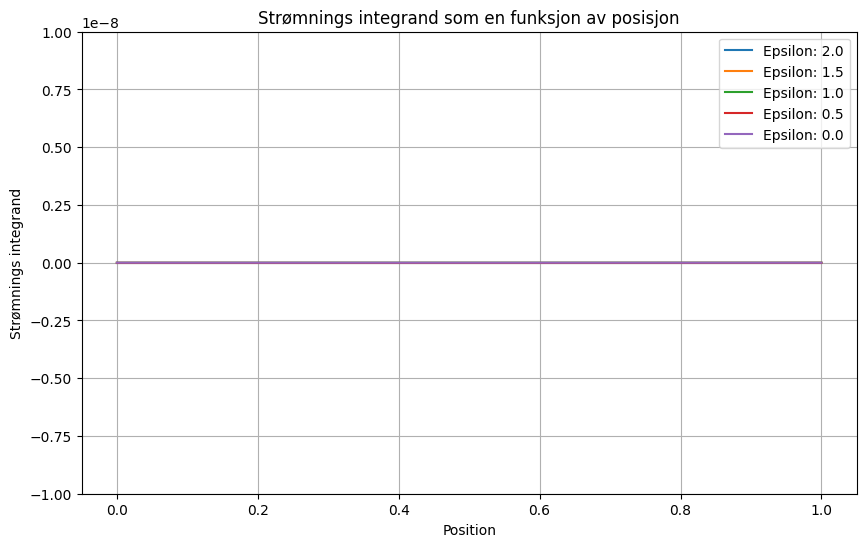

In [21]:
l = 1
m = 100
phiL = 0
phiR = 0

# Setter start verdier
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = np.array([2, 1.5, 1, 0.5, 0])
vLeft, vRight = np.zeros(32), np.zeros(32)

currents = []
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
    currents.append(currentIntegrand(x, sol.sol(x)))
    y = sol.sol(x)

for current, epsilon in zip(currents, epsilons):
    plt.plot(x, current, label=f"Epsilon: {epsilon}")
plt.xlabel('Position')
plt.ylabel('Strømnings integrand')
plt.title('Strømnings integrand som en funksjon av posisjon')
plt.ylim(-10**-8, 10**-8)
plt.legend()
plt.grid(True)
plt.show()

Når $\phi_R = \phi_L = 0$ er det ingen krefter som drar elektron parene i en eller annen retning og det er derfor null "strømtetthet" uansett posisjon. 

## m)

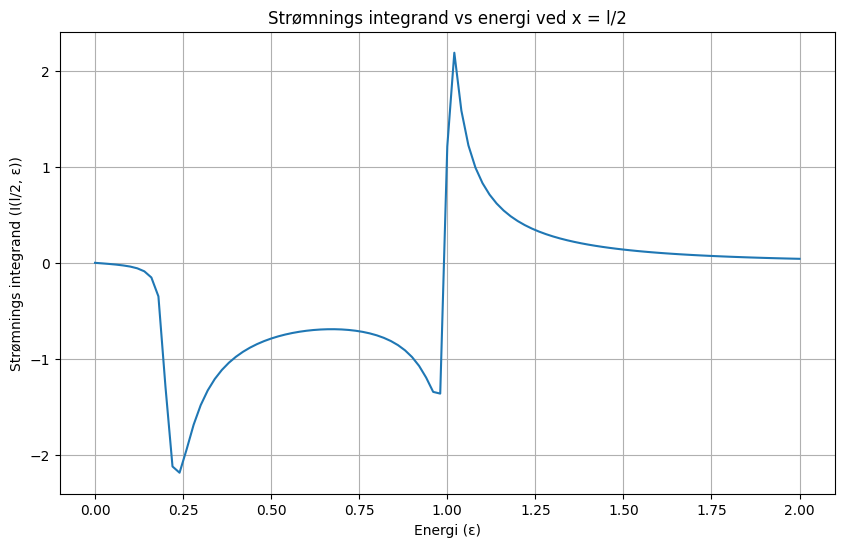

0.5090445706576636


In [ ]:
l = 1
m = 100
phiL = 1
phiR = 0

x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = np.linspace(2, 0, 101)
vLeft, vRight = np.zeros(32), np.zeros(32)

currentIntegrands = []
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
    currentIntegrands.append(currentIntegrand([l/2], sol.sol(l/2)))
    y = sol.sol(x)

plt.plot(epsilons, currentIntegrands)
plt.xlabel('Energi (ε)')
plt.ylabel('Strømnings integrand (I(l/2, ε))')
plt.title('Strømnings integrand vs energi ved x = l/2')
plt.grid(True)
plt.show()

# Skriver ut integralet av strømnings integranden med hensyn på epsilon
print(scipy.integrate.simpson(x=epsilons, y=currentIntegrands))

Her er $\Delta \phi = 1$ og det er derfor en kraft som drar elektron parene. Dette er hvorfor integranden ikke er null, imotsetning til forrige graf når $\Delta \phi = 0$. Formen til integranden(er ikke viktig) bestemmes av greens funksjonen og dens deriverte, og ligner derfor på tetthetsplottet over (som også er en funksjon av greens funksjonen). Strømningsintegranden er den samme over hele lederen, og derfor konservert, fordi superstrømmen må være kontinuerlig. Dette følger av kontinuitetsligningen for ladning, som sikrer at ingen ladning akkumuleres i en stasjonær tilstand.

## n)

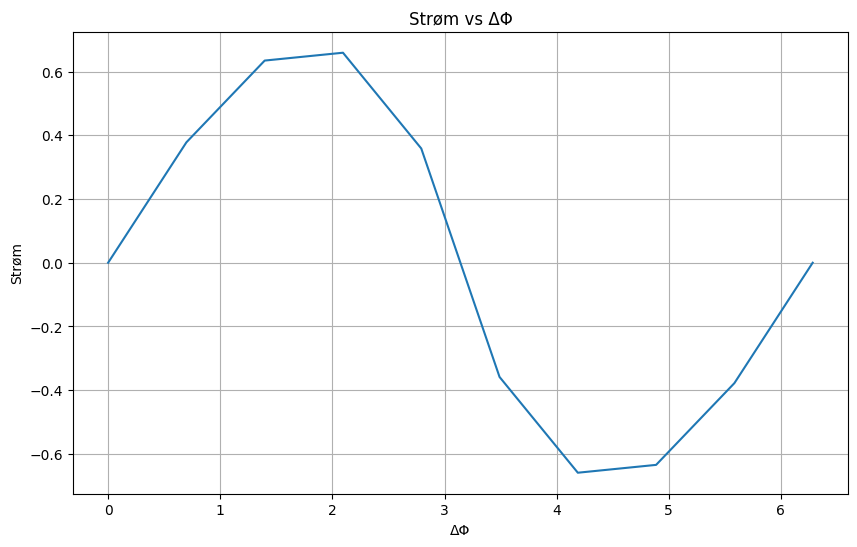

In [23]:
l = 1
m = 100
phiLs = np.linspace(0, 2*np.pi, 10)
phiR = 0


    

current = []
for phiL in phiLs:
    x = np.linspace(0, l, m)
    y = np.zeros((32,m))
    epsilons = np.linspace(2, 0, 101)
    vLeft, vRight = np.zeros(32), np.zeros(32)

    currentIntegrands = []
    for epsilon in epsilons:
        sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
        currentIntegrands.append(currentIntegrand([l/2], sol.sol(l/2)))
        y = sol.sol(x)

    current.append(scipy.integrate.simpson(y=currentIntegrands, x=epsilons))


plt.plot(phiLs, current)
plt.xlabel('ΔΦ')
plt.ylabel('Strøm')
plt.title('Strøm vs ΔΦ')
plt.grid(True)
plt.show()

Her ser man at det er en tydelig superstrøm når $\Delta \phi \not= 0$, hvor retningen og styrken bestemmes av $\Delta \phi$. Man observerer at det er null strøm når $\Delta \phi = 0, \pi $ og $ 2\pi$. Superstrømmen ser ut til å følge en sinusform, som sammensvarer godt med Josephson ligningene. Her kan man se at integralet av integranden i plottet over (som er lik 0.51) samsvarer godt med dette strøm plottet ved $\Delta \phi = 1$

Plottet illustrerer hvordan superstrømmen tydelig avhenger av faseforskjeller mellom superlederne. 
Vi ser at når strømmen er null når superlederne er i fase eller helt ute av fase, hvorimot den er maksimal ved en faseforskjell på $\pi/2$.
 Den sinusoide oppførselen stemmer overens med josephson likningen for strøm i en Josephson junction: $I = I_{c} sin(\Delta \phi)$.